In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn

dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')
dyn.get_all_dependencies_version()

%load_ext autoreload
%autoreload 2

Arial font downloaded successfully to: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered custom font as: Arial


 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



package,ipykernel,setuptools,Pygments,igraph,datacache,tqdm,pynndescent,adjustText,networkx,umap-learn,pandas,get_version,mudata,dynamo-release,patsy,colorcet,numpy,numba,loompy,scikit-learn,seaborn,leidenalg,openpyxl,statsmodels,anndata,matplotlib,numdifftools,scipy,requests
version,6.30.1,80.9.0,2.19.1,1.0.0,1.4.1,4.67.3,0.6.0,1.3.0,3.2.1,0.5.11,2.3.3,3.5.5,0.2.4,1.5.2,1.0.2,3.1.0,2.0.2,0.60.0,3.0.8,1.6.1,0.13.2,0.11.0,3.1.5,0.14.6,0.10.9,3.9.4,0.9.41,1.13.1,2.32.5


In [51]:
import scanpy as sc

In [61]:
adata=dyn.read('ZF3.h5ad')
adata

AnnData object with n_obs × n_vars = 58492 × 26133
    obs: 'clusters'
    obsm: 'X_pca', 'X_tsne'

In [64]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
preprocessor.preprocess_adata(adata, recipe='monocle')

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 0 outlier cells
|-----? No layers exist in adata, skipp filtering by shared counts
|-----------> filtered out 10319 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> computing cell phase...
|-----? 
Dynamo is not able to perform cell cycle staging for you automatically. 
Since dyn.pl.phase_diagram in dynamo by default colors cells by its cell-cycle stage, 
you need to set color argument accordingly if confronting errors related to this.
|-----> [Preprocessor-monocle] completed [8.5860s]

╭─ SUMMARY: Preprocessor.preprocess_adata ───────────────────────────╮
│  Duration: 8.5885s                                                 │
│  Shape:    58,492 x 26,133 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────  

In [66]:
cluster_dict = {
    0: "Nascent forebrain neurons",
    1: "Granule cell neurons",
    2: "Ventral forebrain neurons",
    3: "tcf7l2+, barhl2+ neurons",
    4: "pou4f2+, barhl1a+ neurons",
    5: "Torus Longitudinalis neurons",
    6: "Granule cell neurons",
    7: "GABAergic optic tectum neurons",
    8: "Progenitor cells",
    9: "GABAergic optic tectum neurons",
    10: "GABAergic optic tectum neurons",
    11: "GABAergic optic tectum neurons",
    12: "rtn4rl2b+, eomesa+ pallium neurons",
    13: "atf5b+ neurons",
    14: "nefma+ glutamergic neurons (midbrain)",
    15: "GABAergic subpallium neurons",
    16: "tfap2b+, barhl2+ midbrain neurons",
    17: "Progenitor cells",
    18: "Torus Longitudinalis neurons",
    19: "Progenitor cells",
    20: "fezf1+, otpa+ neurons",
    21: "bnc2+, onecut1+ neurons",
    22: "Progenitor cells",
    23: "GABAergic hindbrain neurons",
    24: "unclassified neurons",
    25: "Radial glia cells (progenitors)",
    26: "Granule cell neurons",
    27: "sst3+ neurons",
    28: "hmx3a+, hmx2+ neurons",
    29: "phox2+ hindbrain neurons",
    30: "penkb+ neurons",
    31: "unclassified neurons",
    32: "rtn4rl2b+ pallium neurons",
    33: "Radial glia cells",
    34: "gng8+ neurons (dorsal habenula)",
    35: "pitx2+ neurons",
    36: "Oligodendrocyte precursor cells",
    37: "prdx1+ neurons",
    38: "pitx2+ neurons",
    39: "Microglia",
    40: "Ependymal cells",
    41: "Granule cell neurons",
    42: "Glutamergic neurons (telencephalon)",
    43: "Purkinje neurons",
    44: "Progenitor cells",
    45: "Oligodendrocytes",
    46: "Erythrocytes",
    47: "Oligodendrocytes",
    48: "Radial glia cells (progenitors)",
    49: "eomesa+ pallium neurons",
    50: "Endothelial cells",
    51: "T-cells/immune cells",
    52: "kiss1+ neurons (ventral habenula)",
    53: "sst1.1+, npy+ neurons",
    54: "Perivascular FGP cells",
    55: "Optic tectum neurons",
    56: "Cranial ganglion",
    57: "Cholinergic neurons",
    58: "Cranial ganglion",
    59: "Endothelial cells",
    60: "Cranial ganglion",
    61: "Statoacoustic ganglion",
    62: "aanat2+ neurons (pineal gland)"
}

In [67]:
adata.obs['cell_type'] = adata.obs['clusters'].astype(int).map(cluster_dict)
adata.obs

,clusters,cell_type,nGenes,nCounts,pMito,pass_basic_filter,Size_Factor,initial_cell_size,ntr
f1_DEW058_bcDQWR,2,Ventral forebrain neurons,2450,2171.061398,0,True,1.347112,2171.061398,None
f1_DEW058_bcAMXL,43,Purkinje neurons,2007,2075.051360,0,True,1.287539,2075.051360,None
f1_DEW058_bcGGJQ,10,GABAergic optic tectum neurons,1516,1920.189209,0,True,1.191449,1920.189209,None
f1_DEW058_bcGDTC,15,GABAergic subpallium neurons,1308,1813.767639,0,True,1.125416,1813.767639,None
f1_DEW058_bcAGDB,1,Granule cell neurons,1028,1580.945932,0,True,0.980954,1580.945932,None
...,...,...,...,...,...,...,...,...,...
hind_1506,23,GABAergic hindbrain neurons,830,1438.016530,0,True,0.892268,1438.016530,None
hind_1507,1,Granule cell neurons,615,1202.357836,0,True,0.746045,1202.357836,None
hind_1508,6,Granule cell neurons,1106,1609.758291,0,True,0.998831,1609.758291,None
hind_1509,17,Progenitor cells,705,1206.405579,0,True,0.748557,1206.405579,None


|-----------> plotting with basis key=X_tsne
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


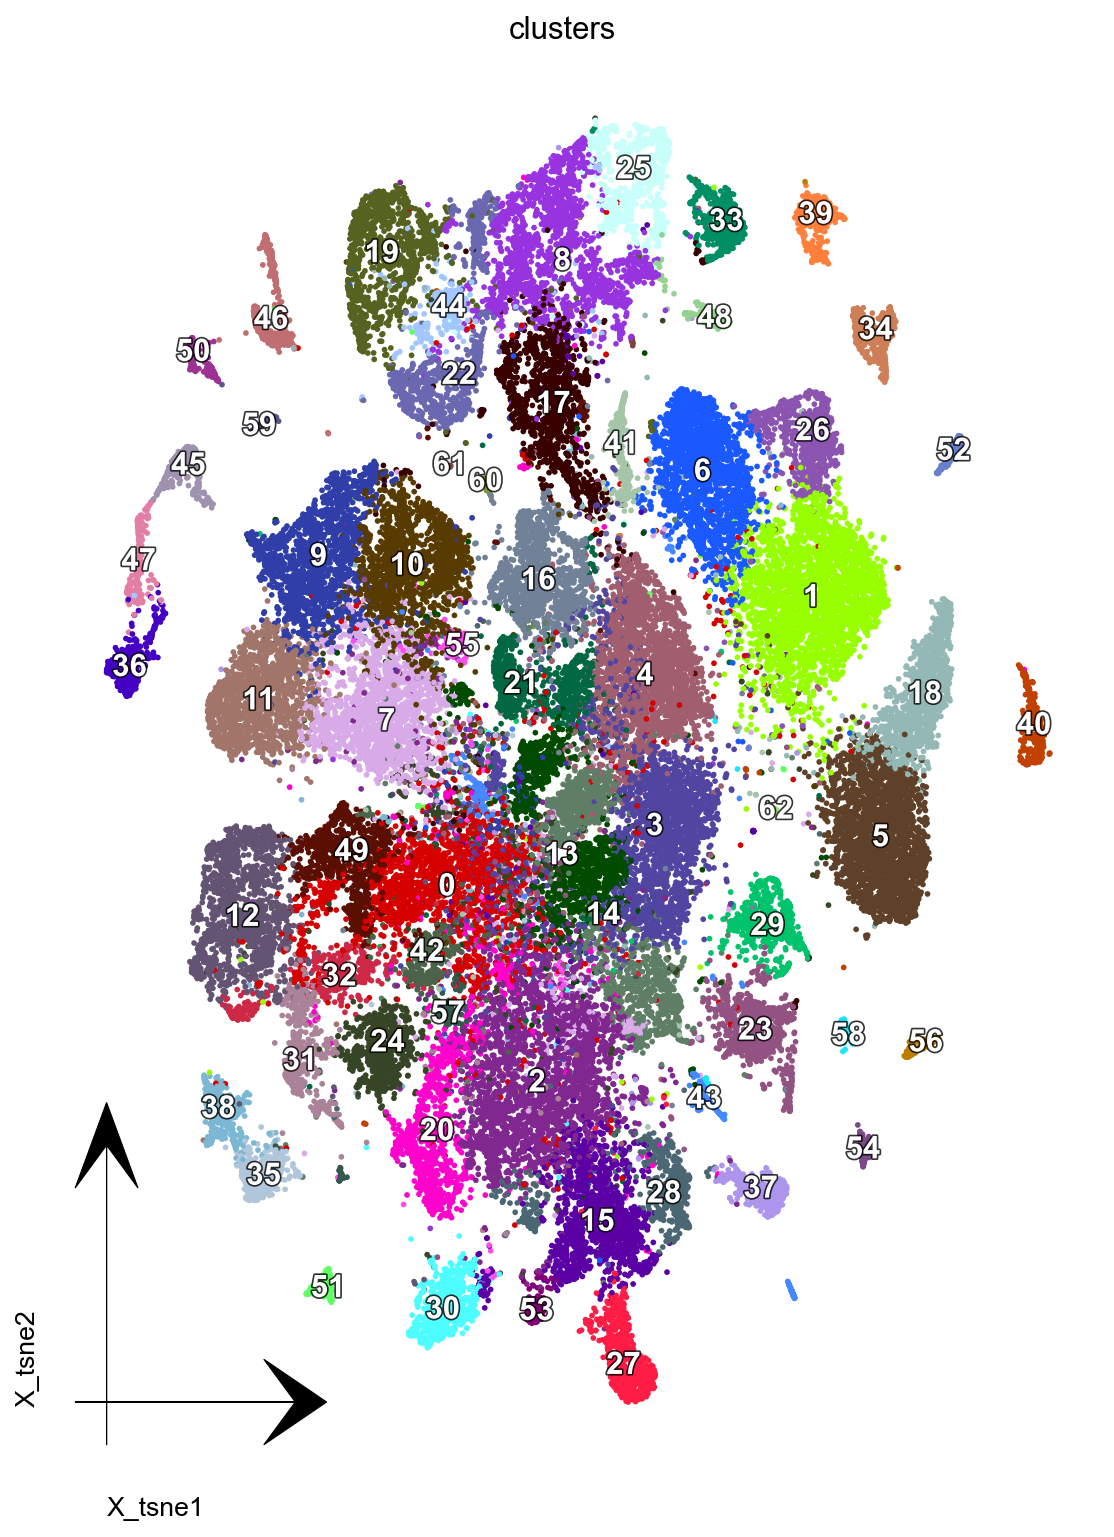

In [69]:
dyn.pl.tsne(adata, color='clusters', 
            figsize=(10,12),pointsize=0.1,alpha=1)

In [70]:
adata.layers['M_s']=adata.X
dyn.tl.pseudotime_velocity(adata,
                          pseudotime='palantir_pseudotime')

|-----> Embrace RNA velocity and velocity vector field analysis for pseudotime...
|-----> Retrieve neighbor graph and pseudotime...

╭─ SUMMARY: pseudotime_velocity ─────────────────────────────────────╮
│  Duration: 0.001s                                                  │
│  Shape:    58,492 x 26,133 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


KeyError: 'distances'